# Notebook 01 — Exploratory Data Analysis

**Goal:** Understand the structure, distribution, and class imbalance 
of the IEEE-CIS Fraud Detection dataset before any modeling.

**Dataset:** IEEE-CIS Fraud Detection Competition (Vesta Corporation)  
**Source:** Kaggle Competition  
**Size:** 590,540 transactions | Two files — Transaction + Identity

## Key Questions
- How imbalanced is the dataset?
- What does the transaction feature distribution look like?
- Are there time-based patterns in fraud?
- How much of the identity data can be merged with transactions?
- Which features correlate most with fraud?

In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

print("All libraries loaded successfully")

All libraries loaded successfully


## 1. Loading the Data

In [2]:
# Load transaction and identity data
train_transaction = pd.read_csv('../data/raw/train_transaction.csv')
train_identity = pd.read_csv('../data/raw/train_identity.csv')

print("Transaction Data Shape:", train_transaction.shape)
print("Identity Data Shape:", train_identity.shape)

Transaction Data Shape: (590540, 394)
Identity Data Shape: (144233, 41)


## 2. Basic Data Overview

In [3]:
# First look at transaction data
print("Transaction Data Info")
print("-" * 50)
print(f"Rows        : {train_transaction.shape[0]:,}")
print(f"Columns     : {train_transaction.shape[1]}")
print(f"Memory Usage: {train_transaction.memory_usage().sum() / 1024**2:.2f} MB")
print()
print("First 5 rows:")
train_transaction.head()

Transaction Data Info
--------------------------------------------------
Rows        : 590,540
Columns     : 394
Memory Usage: 1775.15 MB

First 5 rows:


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5000,W,13926,NaN,150.0000,discover,142.0000,credit,315.0000,87.0000,19.0000,NaN,NaN,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,2.0000,0.0000,1.0000,1.0000,14.0000,NaN,13.0000,NaN,NaN,NaN,NaN,NaN,NaN,13.0000,13.0000,NaN,NaN,NaN,0.0000,T,T,T,M2,F,T,NaN,NaN,NaN,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,117.0000,0.0000,0.0000,0.0000,0.0000,0.0000,117.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,117.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,117.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

## 3. Class Imbalance Analysis

In [4]:
# Check class distribution
fraud_count = train_transaction['isFraud'].value_counts()
fraud_percent = train_transaction['isFraud'].value_counts(normalize=True) * 100

print("Class Distribution")
print("-" * 50)
print(f"Legitimate Transactions : {fraud_count[0]:,} ({fraud_percent[0]:.2f}%)")
print(f"Fraudulent Transactions : {fraud_count[1]:,} ({fraud_percent[1]:.2f}%)")
print(f"Imbalance Ratio         : {fraud_count[0] / fraud_count[1]:.1f}:1")

Class Distribution
--------------------------------------------------
Legitimate Transactions : 569,877 (96.50%)
Fraudulent Transactions : 20,663 (3.50%)
Imbalance Ratio         : 27.6:1


### Observation
The dataset is heavily imbalanced with only 3.50% fraudulent transactions 
and a 27.6:1 imbalance ratio. This means standard accuracy is a misleading 
metric — a model predicting everything as legitimate would still achieve 
96.50% accuracy. We will use F1-score and ROC-AUC as primary evaluation 
metrics and address imbalance through SMOTE and class weighting during 
modeling.

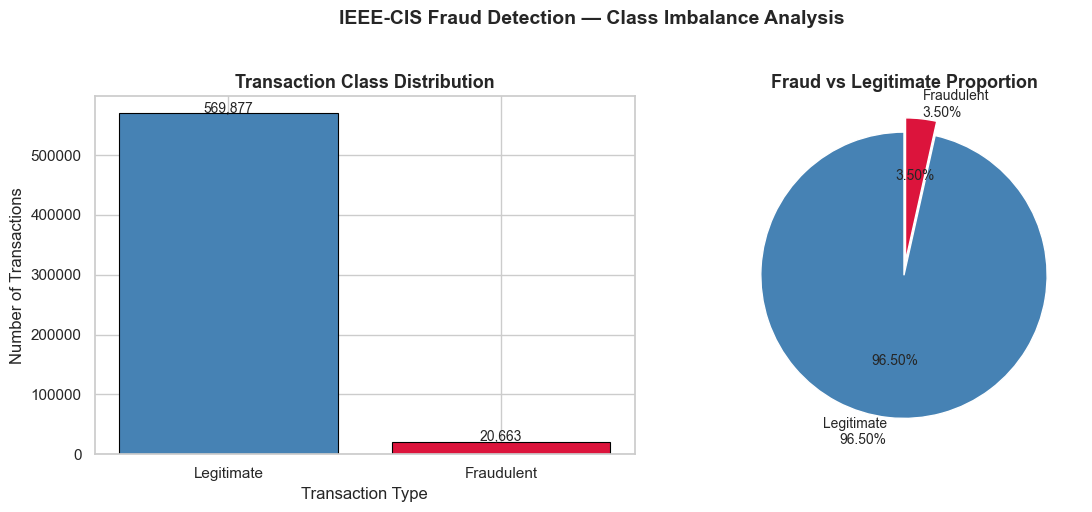

Plot saved to data/processed/class_distribution.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot
axes[0].bar(['Legitimate', 'Fraudulent'], 
            [fraud_count[0], fraud_count[1]], 
            color=['steelblue', 'crimson'],
            edgecolor='black',
            linewidth=0.8)
axes[0].set_title('Transaction Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
axes[0].set_xlabel('Transaction Type')
for i, v in enumerate([fraud_count[0], fraud_count[1]]):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=10)

# Pie chart
axes[1].pie([fraud_percent[0], fraud_percent[1]],
            labels=['Legitimate\n96.50%', 'Fraudulent\n3.50%'],
            colors=['steelblue', 'crimson'],
            explode=(0, 0.1),
            autopct='%1.2f%%',
            startangle=90,
            textprops={'fontsize': 10})
axes[1].set_title('Fraud vs Legitimate Proportion', fontsize=13, fontweight='bold')

plt.suptitle('IEEE-CIS Fraud Detection — Class Imbalance Analysis', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to data/processed/class_distribution.png")

## 4. Transaction Amount Analysis

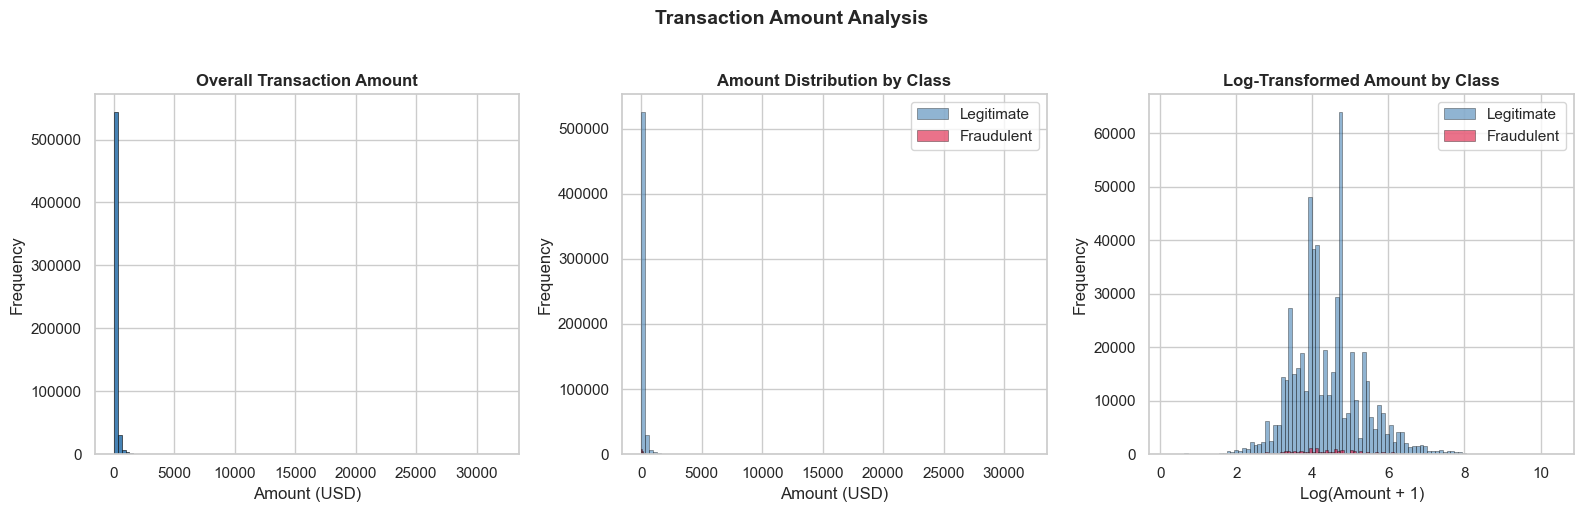

Transaction Amount Summary
--------------------------------------------------
Overall Mean   : $135.03
Overall Median : $68.77
Fraud Mean     : $149.24
Legit Mean     : $134.51
Max Amount     : $31937.39


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Overall amount distribution
axes[0].hist(train_transaction['TransactionAmt'], 
             bins=100, 
             color='steelblue', 
             edgecolor='black',
             linewidth=0.4)
axes[0].set_title('Overall Transaction Amount', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Amount (USD)')
axes[0].set_ylabel('Frequency')

# Amount by class
fraud = train_transaction[train_transaction['isFraud'] == 1]['TransactionAmt']
legit = train_transaction[train_transaction['isFraud'] == 0]['TransactionAmt']

axes[1].hist(legit, bins=100, alpha=0.6, color='steelblue', 
             label='Legitimate', edgecolor='black', linewidth=0.4)
axes[1].hist(fraud, bins=100, alpha=0.6, color='crimson', 
             label='Fraudulent', edgecolor='black', linewidth=0.4)
axes[1].set_title('Amount Distribution by Class', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Amount (USD)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

# Log-transformed amount by class
axes[2].hist(np.log1p(legit), bins=100, alpha=0.6, color='steelblue',
             label='Legitimate', edgecolor='black', linewidth=0.4)
axes[2].hist(np.log1p(fraud), bins=100, alpha=0.6, color='crimson',
             label='Fraudulent', edgecolor='black', linewidth=0.4)
axes[2].set_title('Log-Transformed Amount by Class', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Log(Amount + 1)')
axes[2].set_ylabel('Frequency')
axes[2].legend()

plt.suptitle('Transaction Amount Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics
print("Transaction Amount Summary")
print("-" * 50)
print(f"Overall Mean   : ${train_transaction['TransactionAmt'].mean():.2f}")
print(f"Overall Median : ${train_transaction['TransactionAmt'].median():.2f}")
print(f"Fraud Mean     : ${fraud.mean():.2f}")
print(f"Legit Mean     : ${legit.mean():.2f}")
print(f"Max Amount     : ${train_transaction['TransactionAmt'].max():.2f}")

### Observation
Transaction amounts are right-skewed with a median of $68.77 and max of 
$31,937.39, justifying log-transformation during feature engineering. 
Fraudulent transactions have a slightly higher mean amount $149.24 
compared to legitimate ones $134.51, suggesting transaction amount 
alone is a weak but present signal for fraud detection.

## 5. Time-Based Analysis

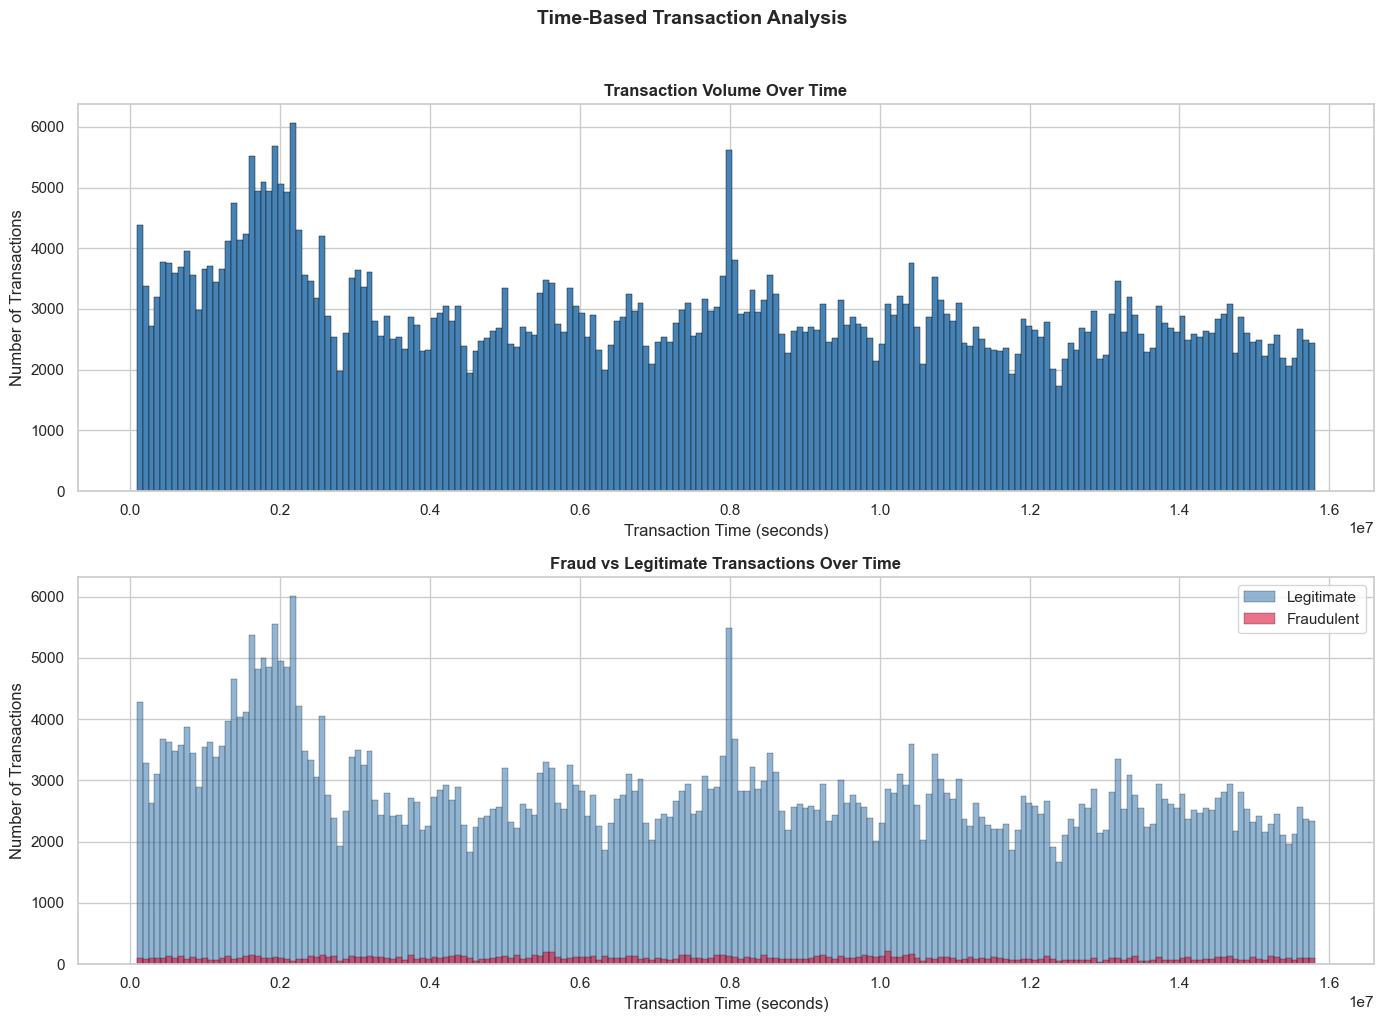

Time-Based Summary
--------------------------------------------------
Time Range     : 86,400 to 15,811,131 seconds
Time Range     : 183 days of data
Fraud Peak Hour: 23:00
Legit Peak Hour: 19:00


In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Transaction volume over time
axes[0].hist(train_transaction['TransactionDT'], 
             bins=200, 
             color='steelblue',
             edgecolor='black',
             linewidth=0.3)
axes[0].set_title('Transaction Volume Over Time', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Transaction Time (seconds)')
axes[0].set_ylabel('Number of Transactions')

# Fraud vs legitimate over time
axes[1].hist(legit_time := train_transaction[train_transaction['isFraud'] == 0]['TransactionDT'],
             bins=200, alpha=0.6, color='steelblue', 
             label='Legitimate', edgecolor='black', linewidth=0.3)
axes[1].hist(fraud_time := train_transaction[train_transaction['isFraud'] == 1]['TransactionDT'],
             bins=200, alpha=0.6, color='crimson',
             label='Fraudulent', edgecolor='black', linewidth=0.3)
axes[1].set_title('Fraud vs Legitimate Transactions Over Time', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Transaction Time (seconds)')
axes[1].set_ylabel('Number of Transactions')
axes[1].legend()

plt.suptitle('Time-Based Transaction Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/time_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Time summary
print("Time-Based Summary")
print("-" * 50)
print(f"Time Range     : {train_transaction['TransactionDT'].min():,} to {train_transaction['TransactionDT'].max():,} seconds")
print(f"Time Range     : {train_transaction['TransactionDT'].max() / (3600*24):.0f} days of data")
print(f"Fraud Peak Hour: {(train_transaction[train_transaction['isFraud']==1]['TransactionDT'] % 86400 // 3600).mode()[0]:.0f}:00")
print(f"Legit Peak Hour: {(train_transaction[train_transaction['isFraud']==0]['TransactionDT'] % 86400 // 3600).mode()[0]:.0f}:00")

### Observation
The dataset spans 183 days of transaction data. A clear behavioral 
difference exists between fraudulent and legitimate transactions in 
terms of timing — fraudulent transactions peak at 23:00 while 
legitimate transactions peak at 19:00. This suggests fraudsters 
prefer late-night hours when monitoring may be reduced. Hour of day 
will be extracted as an important feature during feature engineering.

## 6. Missing Value Analysis

In [8]:
# Calculate missing values for transaction data
missing_transaction = pd.DataFrame({
    'Missing Count': train_transaction.isnull().sum(),
    'Missing Percent': (train_transaction.isnull().sum() / len(train_transaction) * 100).round(2)
})
missing_transaction = missing_transaction[missing_transaction['Missing Count'] > 0]
missing_transaction = missing_transaction.sort_values('Missing Percent', ascending=False)

print("Transaction Data — Missing Value Summary")
print("-" * 50)
print(f"Total Features         : {train_transaction.shape[1]}")
print(f"Features with Missing  : {len(missing_transaction)}")
print(f"Features without Missing: {train_transaction.shape[1] - len(missing_transaction)}")
print()
print("Top 20 Features by Missing Percentage:")
print(missing_transaction.head(20).to_string())

Transaction Data — Missing Value Summary
--------------------------------------------------
Total Features         : 394
Features with Missing  : 374
Features without Missing: 20

Top 20 Features by Missing Percentage:
       Missing Count  Missing Percent
dist2         552913          93.6300
D7            551623          93.4100
D13           528588          89.5100
D14           528353          89.4700
D12           525823          89.0400
D6            517353          87.6100
D8            515614          87.3100
D9            515614          87.3100
V163          508595          86.1200
V166          508589          86.1200
V165          508589          86.1200
V164          508589          86.1200
V147          508595          86.1200
V142          508595          86.1200
V141          508595          86.1200
V140          508595          86.1200
V139          508595          86.1200
V150          508589          86.1200
V149          508595          86.1200
V148          508595 

### Observation
374 out of 394 features (94.9%) contain missing values. The most 
severely affected features include dist2 (93.63%), D7 (93.41%), and 
several D and V feature groups exceeding 86% missingness. This level 
of missingness is common in real-world financial datasets where not 
all transaction metadata is always captured. Strategy during 
preprocessing:
- Features with >90% missing will be dropped
- Features with 50-90% missing will be median/mode imputed
- Features with <50% missing will be carefully imputed using 
  median for numerical and mode for categorical features

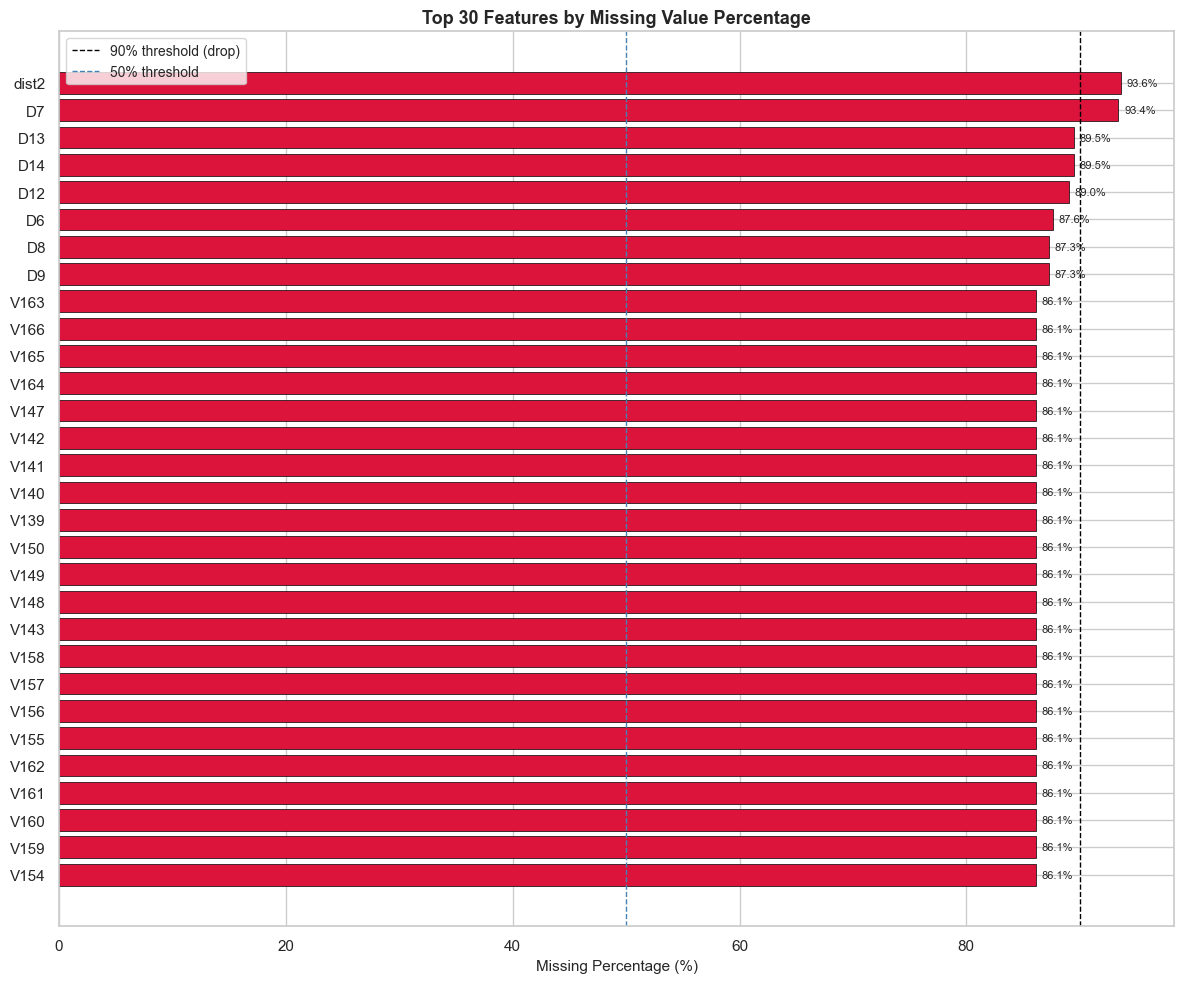

Features to DROP (>90% missing)  : 2
Features to IMPUTE (50-90% missing): 172
Features to IMPUTE (<50% missing) : 200


In [9]:
# Plot top 30 features by missing percentage
top_missing = missing_transaction.head(30)

fig, ax = plt.subplots(figsize=(12, 10))
bars = ax.barh(top_missing.index, 
               top_missing['Missing Percent'],
               color='crimson',
               edgecolor='black',
               linewidth=0.5)

ax.set_xlabel('Missing Percentage (%)', fontsize=11)
ax.set_title('Top 30 Features by Missing Value Percentage', 
             fontsize=13, fontweight='bold')
ax.axvline(x=90, color='black', linestyle='--', 
           linewidth=1, label='90% threshold (drop)')
ax.axvline(x=50, color='steelblue', linestyle='--', 
           linewidth=1, label='50% threshold')
ax.legend(fontsize=10)
ax.invert_yaxis()

for bar, val in zip(bars, top_missing['Missing Percent']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('../data/processed/missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Features to DROP (>90% missing)  : {len(missing_transaction[missing_transaction['Missing Percent'] > 90])}")
print(f"Features to IMPUTE (50-90% missing): {len(missing_transaction[(missing_transaction['Missing Percent'] > 50) & (missing_transaction['Missing Percent'] <= 90)])}")
print(f"Features to IMPUTE (<50% missing) : {len(missing_transaction[missing_transaction['Missing Percent'] <= 50])}")

## 7. Identity Data Analysis

In [10]:
# Missing values in identity data
missing_identity = pd.DataFrame({
    'Missing Count': train_identity.isnull().sum(),
    'Missing Percent': (train_identity.isnull().sum() / len(train_identity) * 100).round(2)
})
missing_identity = missing_identity[missing_identity['Missing Count'] > 0]
missing_identity = missing_identity.sort_values('Missing Percent', ascending=False)

print("Identity Data — Overview")
print("-" * 50)
print(f"Total Rows             : {train_identity.shape[0]:,}")
print(f"Total Features         : {train_identity.shape[1]}")
print(f"Features with Missing  : {len(missing_identity)}")
print()
print("Device Type Distribution:")
print(train_identity['DeviceType'].value_counts())
print()
print("Top 10 Device Info:")
print(train_identity['DeviceInfo'].value_counts().head(10))

Identity Data — Overview
--------------------------------------------------
Total Rows             : 144,233
Total Features         : 41
Features with Missing  : 38

Device Type Distribution:
DeviceType
desktop    85165
mobile     55645
Name: count, dtype: int64

Top 10 Device Info:
DeviceInfo
Windows                  47722
iOS Device               19782
MacOS                    12573
Trident/7.0               7440
rv:11.0                   1901
rv:57.0                    962
SM-J700M Build/MMB29K      549
SM-G610M Build/MMB29K      461
SM-G531H Build/LMY48B      410
rv:59.0                    362
Name: count, dtype: int64


### Observation
Only 144,233 out of 590,540 transactions (24.4%) have corresponding 
identity data. Desktop devices account for 59.1% of transactions with 
identity info, while mobile accounts for 38.6%. Windows is the most 
common platform (47,722 transactions) followed by iOS (19,782). 
The high proportion of transactions without identity data means we 
cannot drop rows missing identity features — instead we will merge 
on TransactionID and treat missing identity fields as a separate 
signal (a missing identity record may itself indicate suspicious 
activity).

## 8. Merging Transaction and Identity Data

In [11]:
# Merge transaction and identity data on TransactionID
df = train_transaction.merge(train_identity, on='TransactionID', how='left')

print("Merged Dataset Summary")
print("-" * 50)
print(f"Transaction Rows       : {train_transaction.shape[0]:,}")
print(f"Identity Rows          : {train_identity.shape[0]:,}")
print(f"Merged Rows            : {df.shape[0]:,}")
print(f"Merged Columns         : {df.shape[1]}")
print()
print("Fraud Distribution After Merge:")
print(f"Legitimate : {df[df['isFraud']==0].shape[0]:,} ({df[df['isFraud']==0].shape[0]/df.shape[0]*100:.2f}%)")
print(f"Fraudulent : {df[df['isFraud']==1].shape[0]:,} ({df[df['isFraud']==1].shape[0]/df.shape[0]*100:.2f}%)")
print()
print("Transactions with Identity Info:")
has_identity = df['DeviceType'].notna().sum()
print(f"With Identity    : {has_identity:,} ({has_identity/df.shape[0]*100:.2f}%)")
print(f"Without Identity : {df.shape[0]-has_identity:,} ({(df.shape[0]-has_identity)/df.shape[0]*100:.2f}%)")

Merged Dataset Summary
--------------------------------------------------
Transaction Rows       : 590,540
Identity Rows          : 144,233
Merged Rows            : 590,540
Merged Columns         : 434

Fraud Distribution After Merge:
Legitimate : 569,877 (96.50%)
Fraudulent : 20,663 (3.50%)

Transactions with Identity Info:
With Identity    : 140,810 (23.84%)
Without Identity : 449,730 (76.16%)


### Observation
Left merge on TransactionID successfully preserved all 590,540 
transactions with 434 total features. Fraud distribution remains 
unchanged at 3.50% confirming no data loss during merge. Only 23.84% 
of transactions have identity information — the remaining 76.16% will 
have NaN identity fields which will be treated as a feature signal 
during modeling. A binary flag 'has_identity' will be created during 
feature engineering to capture this pattern explicitly.

## 9. Categorical Feature Analysis

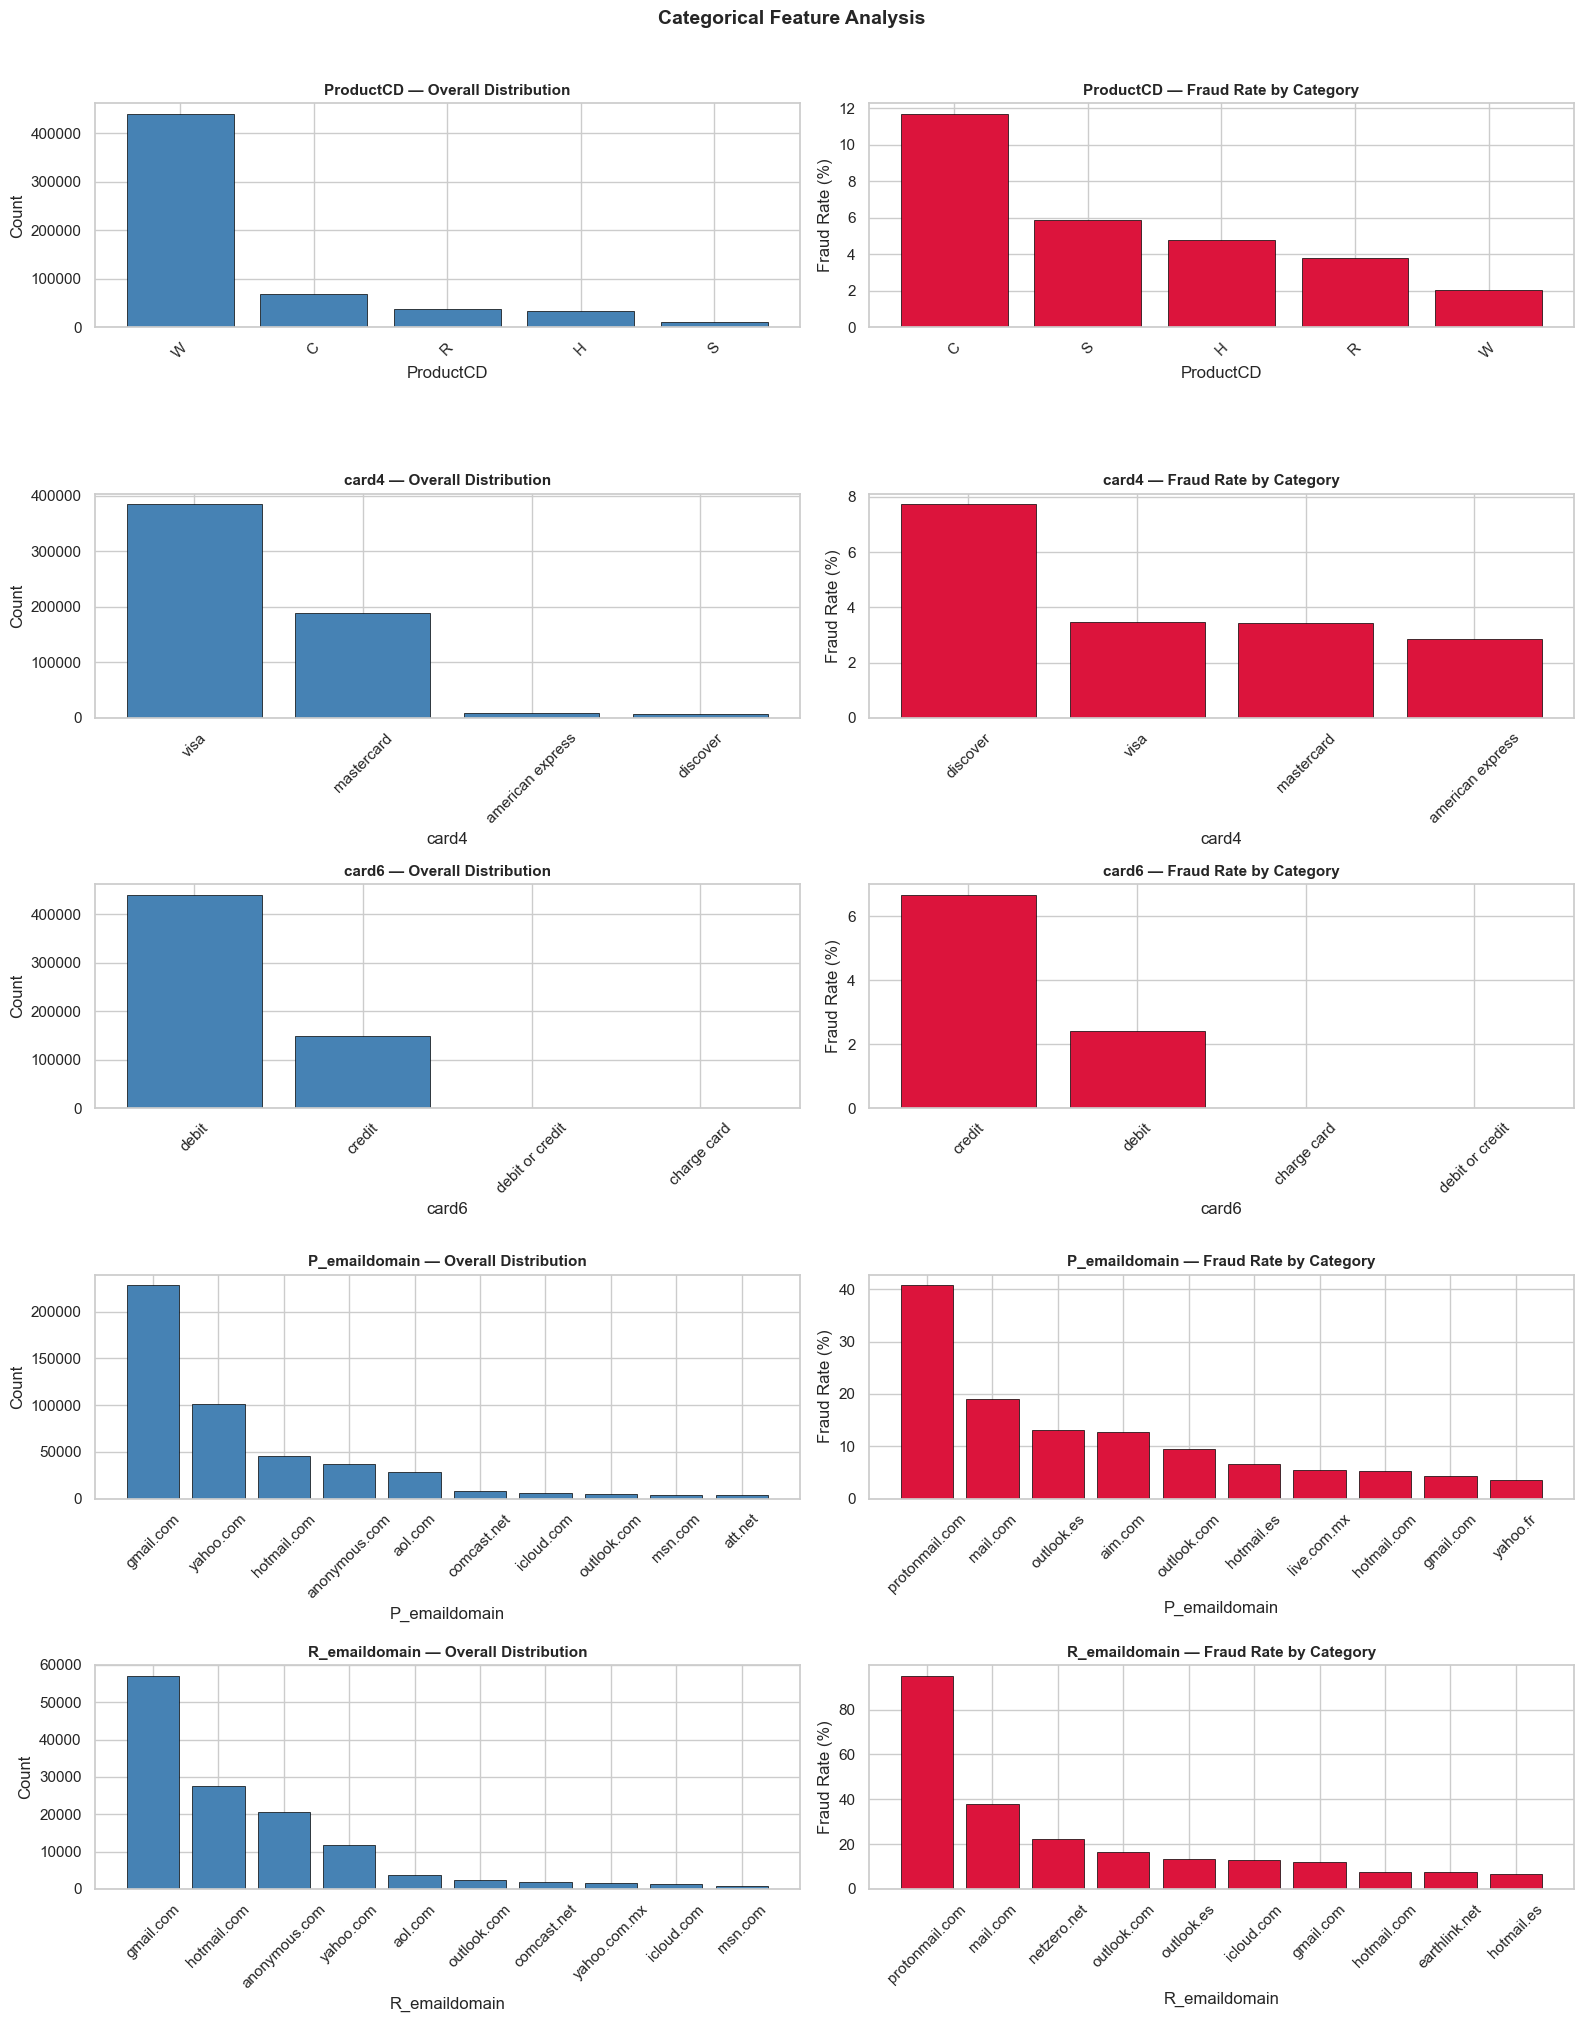

Fraud Rate by ProductCD
--------------------------------------------------
ProductCD
C   11.6900
H    4.7700
R    3.7800
S    5.9000
W    2.0400

Fraud Rate by Card Type (card4)
--------------------------------------------------
card4
american express   2.8700
discover           7.7300
mastercard         3.4300
visa               3.4800


In [12]:
# Identify categorical columns
cat_cols = ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain']

fig, axes = plt.subplots(len(cat_cols), 2, figsize=(16, 20))

for i, col in enumerate(cat_cols):
    # Value counts
    val_counts = df[col].value_counts().head(10)
    
    # Overall distribution
    axes[i, 0].bar(val_counts.index, val_counts.values,
                   color='steelblue', edgecolor='black', linewidth=0.5)
    axes[i, 0].set_title(f'{col} — Overall Distribution', 
                          fontsize=11, fontweight='bold')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Count')
    axes[i, 0].tick_params(axis='x', rotation=45)

    # Fraud rate by category
    fraud_rate = df.groupby(col)['isFraud'].mean().sort_values(ascending=False).head(10)
    axes[i, 1].bar(fraud_rate.index, fraud_rate.values * 100,
                   color='crimson', edgecolor='black', linewidth=0.5)
    axes[i, 1].set_title(f'{col} — Fraud Rate by Category',
                          fontsize=11, fontweight='bold')
    axes[i, 1].set_xlabel(col)
    axes[i, 1].set_ylabel('Fraud Rate (%)')
    axes[i, 1].tick_params(axis='x', rotation=45)

plt.suptitle('Categorical Feature Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/processed/categorical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Print fraud rates
print("Fraud Rate by ProductCD")
print("-" * 50)
print((df.groupby('ProductCD')['isFraud'].mean() * 100).round(2).to_string())
print()
print("Fraud Rate by Card Type (card4)")
print("-" * 50)
print((df.groupby('card4')['isFraud'].mean() * 100).round(2).to_string())

### Observation
Significant fraud rate variation exists across categorical features:

- ProductCD: Product C has the highest fraud rate (11.69%) — nearly 
  3x higher than Product W (2.04%). This makes ProductCD one of the 
  strongest categorical predictors.
  
- Card Type: Discover cards show the highest fraud rate (7.73%) — 
  2.7x higher than American Express (2.87%). Visa and Mastercard are 
  similar at ~3.4%.

These categorical features will be label encoded and included as 
high-priority features during modeling.

## 10. Correlation Analysis

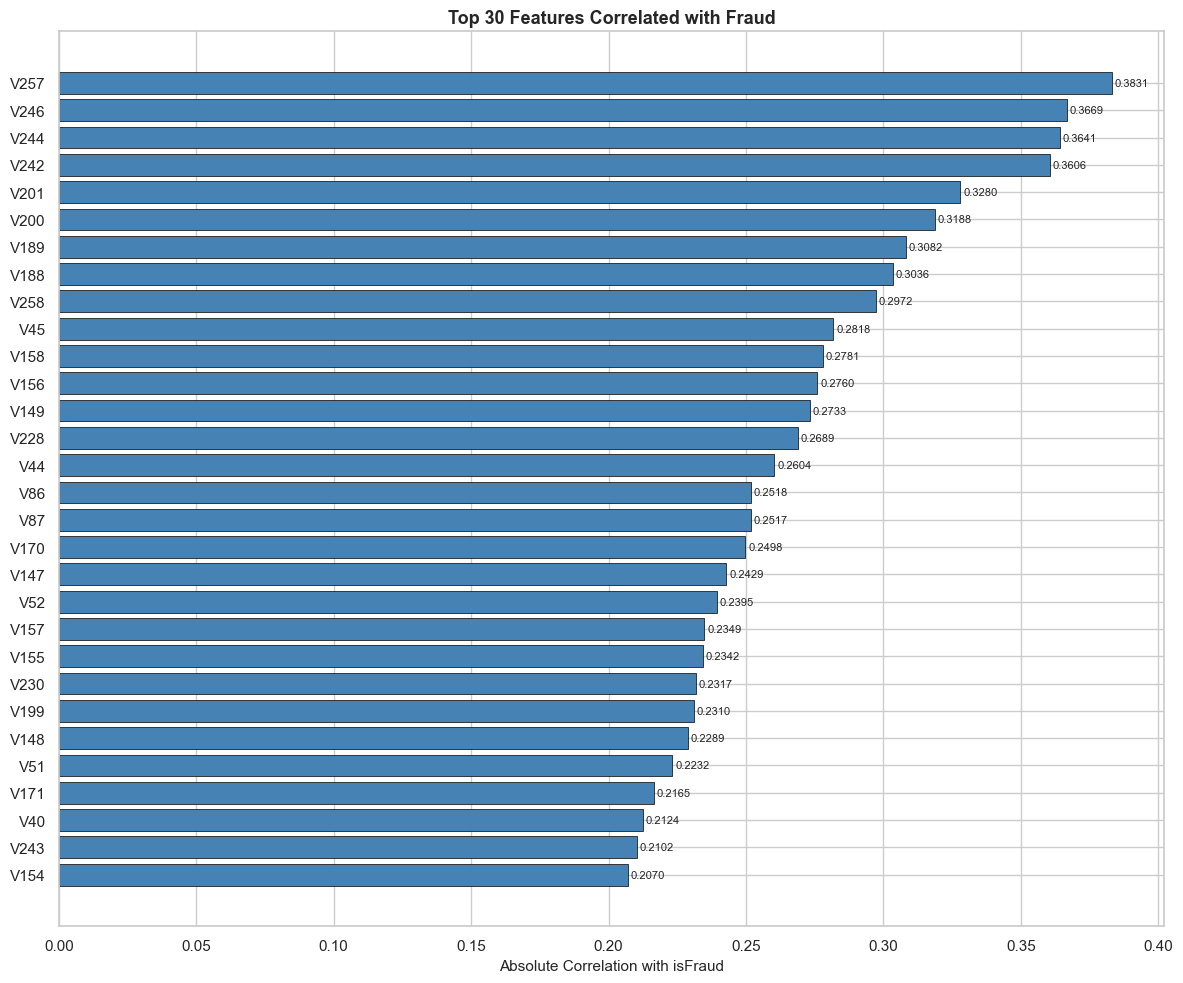

Top 10 Features Correlated with Fraud
--------------------------------------------------
V257   0.3831
V246   0.3669
V244   0.3641
V242   0.3606
V201   0.3280
V200   0.3188
V189   0.3082
V188   0.3036
V258   0.2972
V45    0.2818


In [13]:
# Select numerical columns only
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [col for col in num_cols if col != 'isFraud']

# Correlation with target
corr_with_target = df[num_cols].corrwith(df['isFraud']).abs()
corr_with_target = corr_with_target.sort_values(ascending=False).dropna()

# Plot top 30 correlated features
top_corr = corr_with_target.head(30)

fig, ax = plt.subplots(figsize=(12, 10))
bars = ax.barh(top_corr.index,
               top_corr.values,
               color='steelblue',
               edgecolor='black',
               linewidth=0.5)
ax.set_xlabel('Absolute Correlation with isFraud', fontsize=11)
ax.set_title('Top 30 Features Correlated with Fraud', 
             fontsize=13, fontweight='bold')
ax.invert_yaxis()

for bar, val in zip(bars, top_corr.values):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('../data/processed/correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 Features Correlated with Fraud")
print("-" * 50)
print(corr_with_target.head(10).to_string())

### Observation
The top correlated features with fraud are all V-features (Vesta's 
proprietary engineered features), with V257 leading at 0.3831 
correlation. No single feature dominates strongly (max 0.38), 
confirming this is a complex classification problem requiring 
ensemble methods rather than simple linear models. The top 10 
features are all V-features in the 188-258 range, suggesting 
this feature group captures the most fraud signal and will be 
prioritized during feature selection.

## 11. EDA Summary

In [14]:
print("=" * 60)
print("EDA SUMMARY — IEEE-CIS Fraud Detection")
print("=" * 60)
print()
print("Dataset")
print("-" * 40)
print(f"Total Transactions     : {df.shape[0]:,}")
print(f"Total Features         : {df.shape[1]}")
print(f"Date Range             : 183 days")
print()
print("Class Imbalance")
print("-" * 40)
print(f"Legitimate             : 569,877 (96.50%)")
print(f"Fraudulent             : 20,663 (3.50%)")
print(f"Imbalance Ratio        : 27.6:1")
print()
print("Missing Values")
print("-" * 40)
print(f"Features to Drop       : 2  (>90% missing)")
print(f"Features to Impute     : 372 (remaining)")
print()
print("Key Findings")
print("-" * 40)
print("1. Fraud peaks at 23:00 vs legitimate at 19:00")
print("2. Product C has highest fraud rate at 11.69%")
print("3. Discover cards have highest fraud rate at 7.73%")
print("4. Fraud mean amount ($149) > Legitimate ($134)")
print("5. V-features (V257, V246, V244) are strongest predictors")
print("6. Only 23.84% transactions have identity data")
print()
print("Modeling Strategy")
print("-" * 40)
print("- Primary Metric  : F1-Score and ROC-AUC (not accuracy)")
print("- Imbalance       : SMOTE + class weighting")
print("- Missing Values  : Drop >90%, impute remainder")
print("- Models          : Logistic Regression, Random Forest,")
print("                    XGBoost, LightGBM")
print("=" * 60)

EDA SUMMARY — IEEE-CIS Fraud Detection

Dataset
----------------------------------------
Total Transactions     : 590,540
Total Features         : 434
Date Range             : 183 days

Class Imbalance
----------------------------------------
Legitimate             : 569,877 (96.50%)
Fraudulent             : 20,663 (3.50%)
Imbalance Ratio        : 27.6:1

Missing Values
----------------------------------------
Features to Drop       : 2  (>90% missing)
Features to Impute     : 372 (remaining)

Key Findings
----------------------------------------
1. Fraud peaks at 23:00 vs legitimate at 19:00
2. Product C has highest fraud rate at 11.69%
3. Discover cards have highest fraud rate at 7.73%
4. Fraud mean amount ($149) > Legitimate ($134)
5. V-features (V257, V246, V244) are strongest predictors
6. Only 23.84% transactions have identity data

Modeling Strategy
----------------------------------------
- Primary Metric  : F1-Score and ROC-AUC (not accuracy)
- Imbalance       : SMOTE + class 

## 12. Next Steps

- Phase 2: Feature Engineering
    - Extract hour, day, week from TransactionDT
    - Log-transform TransactionAmt
    - Create has_identity binary flag
    - Encode categorical features
    - Drop features with >90% missing
    - Impute remaining missing values
    - Build sklearn preprocessing pipeline